In [1]:
from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:4b",
    enable_thinking=False,
    temperature=0,
    reasoning=False,
)

In [59]:
from exa_py import Exa
from langchain_core.tools import tool

exa = Exa("ffb748ad-c1a9-49ca-ade6-407f7dcfacf5")

@tool
def web_search(query: str) -> str:
    """Search the web for current information."""

    response = exa.search(
        query,
        num_results=5
    )

    return "\n\n".join(
        f"Title: {result.title}\n"
        f"URL: {result.url}"
        for result in response.results
    )

In [62]:
tools = [web_search]

In [63]:
llm_with_tools = llm.bind_tools(tools)

In [64]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    """
    Messages have the type "list". The "add messages' function
    in the annotation defines how this state key should be updated
    (in this case, it appends messages to the list, rather than overwriting them.)
    """
    messages: Annotated[list, add_messages]


def llm_call(state:State):
    response = {"messages": [llm_with_tools.invoke(state["messages"])]}

    return response


graph_builder = StateGraph(State)


graph_builder.add_edge(START, "llm_call")
graph_builder.add_node("llm_call", llm_call)

graph_builder.add_conditional_edges("llm_call", tools_condition)

graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_edge("tools", "llm_call")


graph = graph_builder.compile()



In [65]:
response = graph.invoke({"messages": "Can you find me used gaming laptops under 160k pkr? and then give me latest AI news"})

In [66]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Can you find me used gaming laptops under 160k pkr? and then give me latest AI news
================================== Ai Message ==================================
Tool Calls:
  web_search (ea5f717c-337e-4fb7-b9f7-19f8c21df2e3)
 Call ID: ea5f717c-337e-4fb7-b9f7-19f8c21df2e3
  Args:
    query: used gaming laptops under 160000 PKR Pakistan
  web_search (c4ab3f97-38a5-4068-a744-63633a0e4c8f)
 Call ID: c4ab3f97-38a5-4068-a744-63633a0e4c8f
  Args:
    query: latest AI news 2024
================================= Tool Message =================================
Name: web_search

Title: Dell G15 5520 i7-12700H Gaming 16GB 512GB SSD Price PK
URL: https://nnlaptops.com/product/dell-g15-5520-i7-12700h-16gb-512gb-rtx3060

Title: Used ASUS ROG Zephyrus G14 Ryzen 7 RTX 2060 Price Pakistan
 – ASK Laptops
URL: https://asklaptopstore.com/products/asus-rog-zephyrus-g14-ryzen-7-4800hs-laptop-price-in-pakistan

Title: Buy Use

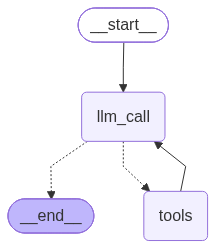

In [43]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

# MEMORY SAVER

In [72]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver, MemorySaver

memory = InMemorySaver()

class State(TypedDict):
    """
    Messages have the type "list". The "add messages' function
    in the annotation defines how this state key should be updated
    (in this case, it appends messages to the list, rather than overwriting them.)
    """
    messages: Annotated[list, add_messages]


def llm_call(state:State):
    response = {"messages": [llm_with_tools.invoke(state["messages"])]}

    return response


graph_builder = StateGraph(State)


graph_builder.add_edge(START, "llm_call")
graph_builder.add_node("llm_call", llm_call)

graph_builder.add_conditional_edges("llm_call", tools_condition)

graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_edge("tools", "llm_call")


graph = graph_builder.compile(checkpointer=memory)



In [73]:
config = {"configurable": {"thread_id": "1"}}

In [75]:
response = graph.invoke({"messages": "Hi How are you I'm Faaiz Ali"}, config=config)

In [83]:
response['messages'][-1].content

'Your name is **Faaiz Ali**.'

In [77]:
response = graph.invoke({"messages": "What is my Name?"}, config=config)

In [82]:
response['messages'][-1].content

'Your name is **Faaiz Ali**.'

# STREAMING

In [85]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver, MemorySaver

memory = InMemorySaver()

class State(TypedDict):
    """
    Messages have the type "list". The "add messages' function
    in the annotation defines how this state key should be updated
    (in this case, it appends messages to the list, rather than overwriting them.)
    """
    messages: Annotated[list, add_messages]


def chatbot(state:State):
    response = {"messages": [llm_with_tools.invoke(state["messages"])]}

    return response


builder = StateGraph(State)

builder.add_edge(START, "chatbot")
builder.add_node("chatbot", chatbot)
builder.add_edge("chatbot", END)

graph = builder.compile(checkpointer=memory)

In [86]:
for chunk in graph.stream({"messages": "Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan"}, config=config, stream_mode="updates"):
    print(chunk)


{'chatbot': {'messages': [AIMessage(content="Hello Faaiz! It's great to meet you. Cricket is a wonderful sport, especially in Pakistan where it holds such a special place in the hearts of people.\n\nIs there anything specific about cricket you'd like to discuss? Maybe your favorite players, teams, or perhaps you're looking for information on an upcoming match?", additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-09-25T08:10:12.942765379Z', 'done': True, 'done_reason': 'stop', 'total_duration': 34638016979, 'load_duration': 5607904858, 'prompt_eval_count': 285, 'prompt_eval_duration': 18039269000, 'eval_count': 67, 'eval_duration': 10987666000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--01a0d79c-e2ff-72a3-a104-91907a1f50e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 285, 'output_tokens': 67, 'total_tokens': 352})]}}


In [87]:
for chunk in graph.stream({"messages": "Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan"}, config=config, stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content="Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan", additional_kwargs={}, response_metadata={}, id='ffd7d1e7-b5cf-4fde-a95c-065c858bc73d'), AIMessage(content="Hello Faaiz! It's great to meet you. Cricket is a wonderful sport, especially in Pakistan where it holds such a special place in the hearts of people.\n\nIs there anything specific about cricket you'd like to discuss? Maybe your favorite players, teams, or perhaps you're looking for information on an upcoming match?", additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-09-25T08:10:12.942765379Z', 'done': True, 'done_reason': 'stop', 'total_duration': 34638016979, 'load_duration': 5607904858, 'prompt_eval_count': 285, 'prompt_eval_duration': 18039269000, 'eval_count': 67, 'eval_duration': 10987666000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--01a0d79c-e2ff-72a3-a104-91907a1f50e4-0', tool_calls=[], invalid_tool_call

In [89]:
config = {"configurable": {"thread_id": "2"}}

async for chunk in graph.astream_events({"messages": "Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan"}, config=config, stream_mode="values"):
    print(chunk)


{'event': 'on_chain_start', 'data': {'input': {'messages': "Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan"}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0d830-8cd1-7092-adb1-3d6e76916153', 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '01a0d830-8cd1-7092-adb1-3d6e76916153', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content="Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan", additional_kwargs={}, response_metadata={}, id='2d1ff969-99b9-4732-b3f3-47fa24935be5')]}}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content="Hi I'm Faaiz Ali and I love cricket, I'm from Pakistan", additional_kwargs={}, response_metadata={}, id='2d1ff969-99b9-4732-b3f3-47fa24935be5')]}}, 'name': 'chatbot', 'tags': ['graph:step:1'], 'run_id': '01a0d830-8cd3-77b3-b338-9e27e9bad0c6